# K* (K-Star) Means Clustering on Preprocessed Telco Dataset

This notebook implements K* (K-star) means clustering, an algorithm that automatically determines the optimal number of clusters using Minimum Description Length (MDL) principle.

**Key Features:**
- Automatically finds optimal K (no need to specify number of clusters)
- Uses MDL cost function for model selection
- Performs adaptive splitting and merging of clusters

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import kmeans_plusplus
from sklearn.metrics import (
    silhouette_score, 
    davies_bouldin_score, 
    calinski_harabasz_score
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## K* Means Implementation

Implementation of K* Means algorithm with MDL-based automatic cluster number selection.

In [66]:
class KStarMeans:
    """K*-means clustering with automatic K determination using MDL principle.
    
    Implements the algorithm from the paper with proper split/merge operations.
    """
    def __init__(self, patience=5):
        self.patience = patience    # termination criteria
        self.centroids = None
        self.labels = None
        self.sub_centroids = {}     # Stores (mu_s1, mu_s2) for each cluster
        self.clusters = {}          # Stores actual cluster assignments

    def _mdl_cost(self, X, centroids, labels):
        """Calculate MDL cost as per pseudocode: modelcost + idxcost + residualcost"""
        N, d = X.shape
        k = len(centroids)
        if k == 0: return np.inf
        
        # Calculate float precision from data
        # Find minimum non-zero distance between any values
        flat_X = X.flatten()
        unique_vals = np.unique(flat_X)
        if len(unique_vals) > 1:
            min_dist = np.min(np.diff(np.sort(unique_vals)))
            if min_dist > 0:
                floatprecision = -np.log2(min_dist)
            else:
                floatprecision = 10.0  # default
        else:
            floatprecision = 10.0
        
        # Model Cost: |C| * d * floatcost
        floatcost = (np.max(X) - np.min(X)) / floatprecision
        modelcost = k * d * floatcost
        
        # Index Cost: |X| * log(|C|)
        idxcost = N * np.log2(k) if k > 1 else 0
        
        # Residual Cost: sum of squared distances from centroids
        c = 0
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                c += np.sum((cluster_points - centroids[i])**2)
        
        residualcost = 0.5 * (N * d * np.log2(2 * np.pi) + c)
        
        return modelcost + idxcost + residualcost

    def _init_subcentroids(self, cluster_data):
        """Initialize two subcentroids using k-means++."""
        if len(cluster_data) < 2:
            return cluster_data[0], cluster_data[0]
        centers, _ = kmeans_plusplus(cluster_data, n_clusters=2)
        return centers[0], centers[1]

    def _kmeans_step(self, X):
        """Perform one iteration of k-means assignment and update."""
        # Assign points to nearest centroid
        dists = np.linalg.norm(X[:, np.newaxis] - np.array(self.centroids), axis=2)
        self.labels = np.argmin(dists, axis=1)
        
        # Update centroids and subclusters
        for i in range(len(self.centroids)):
            cluster_points = X[self.labels == i]
            if len(cluster_points) > 0:
                # Update main centroid
                self.centroids[i] = np.mean(cluster_points, axis=0)
                
                # Update sub-centroids if cluster has enough points
                if len(cluster_points) >= 2:
                    if i not in self.sub_centroids or len(cluster_points) == 2:
                        self.sub_centroids[i] = self._init_subcentroids(cluster_points)
                    else:
                        # Update existing subcentroids
                        s1, s2 = self.sub_centroids[i]
                        d1 = np.linalg.norm(cluster_points - s1, axis=1)
                        d2 = np.linalg.norm(cluster_points - s2, axis=1)
                        sub_labels = d1 < d2
                        
                        if np.any(sub_labels) and np.any(~sub_labels):
                            s1_new = np.mean(cluster_points[sub_labels], axis=0)
                            s2_new = np.mean(cluster_points[~sub_labels], axis=0)
                            self.sub_centroids[i] = (s1_new, s2_new)

    def _maybe_split(self, X):
        """Try to split the cluster that would most reduce MDL cost."""
        N = len(X)
        k = len(self.centroids)
        current_cost = self._mdl_cost(X, self.centroids, self.labels)
        best_cost = current_cost
        split_at = -1
        
        # Try splitting each cluster and calculate actual MDL cost
        for i in range(k):
            cluster_points = X[self.labels == i]
            if len(cluster_points) < 2 or i not in self.sub_centroids:
                continue
            
            # Get subclusters
            s1, s2 = self.sub_centroids[i]
            d1 = np.linalg.norm(cluster_points - s1, axis=1)
            d2 = np.linalg.norm(cluster_points - s2, axis=1)
            
            # Simulate split: temporarily create new clustering
            temp_centroids = self.centroids.copy()
            temp_centroids[i] = s1.copy()
            temp_centroids.append(s2.copy())
            
            # Reassign labels with new centroids
            dists = np.linalg.norm(X[:, np.newaxis] - np.array(temp_centroids), axis=2)
            temp_labels = np.argmin(dists, axis=1)
            
            # Calculate actual MDL cost with this split
            split_cost = self._mdl_cost(X, temp_centroids, temp_labels)
            
            if split_cost < best_cost:
                best_cost = split_cost
                split_at = i
        
        # Perform split if it reduces cost
        did_split = False
        split_info = None
        if split_at >= 0 and best_cost < current_cost:
            s1, s2 = self.sub_centroids[split_at]
            # Replace old centroid with s1, add s2 as new centroid
            self.centroids[split_at] = s1.copy()
            self.centroids.append(s2.copy())
            
            # Re-assign all points
            self._kmeans_step(X)
            
            # Initialize new subcentroids for both split clusters
            for idx in [split_at, len(self.centroids)-1]:
                cluster_points = X[self.labels == idx]
                if len(cluster_points) >= 2:
                    self.sub_centroids[idx] = self._init_subcentroids(cluster_points)
            
            did_split = True
            split_info = (split_at, len(self.centroids), current_cost, best_cost)
        
        return did_split, split_info

    def _maybe_merge(self, X):
        """Try to merge the closest pair of centroids if it reduces MDL cost."""
        N = len(X)
        k = len(self.centroids)
        if k < 2:
            return False, None
        
        current_cost = self._mdl_cost(X, self.centroids, self.labels)
        best_cost = current_cost
        merge_pair = None
        
        # Try merging each pair of closest centroids
        centroids_array = np.array(self.centroids)
        
        # Find all pairs and their distances
        for i1 in range(k):
            for i2 in range(i1 + 1, k):
                # Simulate merge
                cluster1 = X[self.labels == i1]
                cluster2 = X[self.labels == i2]
                Z = np.vstack([cluster1, cluster2])
                m_merged = np.mean(Z, axis=0)
                
                # Create temporary centroids with merge
                temp_centroids = [self.centroids[j] for j in range(k) if j not in [i1, i2]]
                temp_centroids.append(m_merged)
                
                # Reassign labels with merged centroids
                dists = np.linalg.norm(X[:, np.newaxis] - np.array(temp_centroids), axis=2)
                temp_labels = np.argmin(dists, axis=1)
                
                # Calculate actual MDL cost with this merge
                merge_cost = self._mdl_cost(X, temp_centroids, temp_labels)
                
                if merge_cost < best_cost:
                    best_cost = merge_cost
                    merge_pair = (i1, i2, m_merged)
        
        # Perform merge if it reduces cost
        did_merge = False
        merge_info = None
        if merge_pair is not None and best_cost < current_cost:
            i1, i2, m_merged = merge_pair
            old_k = len(self.centroids)
            
            # Remove both clusters and add merged
            if i1 > i2:
                i1, i2 = i2, i1
            
            # Replace first centroid with merged, remove second
            self.centroids[i1] = m_merged
            del self.centroids[i2]
            
            # Update subcentroids dictionary
            if i2 in self.sub_centroids:
                del self.sub_centroids[i2]
            
            # Re-assign all points
            self._kmeans_step(X)
            
            # Reinitialize subcentroids for merged cluster
            cluster_points = X[self.labels == i1]
            if len(cluster_points) >= 2:
                self.sub_centroids[i1] = self._init_subcentroids(cluster_points)
            
            did_merge = True
            merge_info = (i1, i2, old_k, len(self.centroids), current_cost, best_cost)
        
        return did_merge, merge_info

    def fit(self, X):
        """Fit K*-means to data X following the pseudocode algorithm."""
        N, d = X.shape
        
        # Initialize with one cluster
        self.centroids = [np.mean(X, axis=0)]
        self.labels = np.zeros(N, dtype=int)
        self.sub_centroids = {0: self._init_subcentroids(X)}
        
        best_cost = np.inf
        unimproved_count = 0
        iteration = 0
        
        print("Starting K* Means iterations...")
        print("="*70)
        
        while True:
            iteration += 1
            
            # KmeansStep
            self._kmeans_step(X)
            
            # MaybeSplit
            did_split, split_info = self._maybe_split(X)
            
            # If no split, do KmeansStep again then MaybeMerge
            did_merge = False
            merge_info = None
            if not did_split:
                self._kmeans_step(X)
                did_merge, merge_info = self._maybe_merge(X)
            
            # Calculate cost and check improvement
            cost = self._mdl_cost(X, self.centroids, self.labels)
            k = len(self.centroids)
            
            # Print iteration info
            action = ""
            if did_split:
                action = f"✂️  SPLIT cluster {split_info[0]} → K={split_info[1]} (MDL: {split_info[2]:.0f}→{split_info[3]:.0f})"
            elif did_merge:
                action = f"🔗 MERGE clusters {merge_info[0]} & {merge_info[1]}: K={merge_info[2]}→{merge_info[3]} (MDL: {merge_info[4]:.0f}→{merge_info[5]:.0f})"
            else:
                action = "⏸️  No split/merge"
            
            improvement = ""
            if cost < best_cost:
                best_cost = cost
                unimproved_count = 0
                improvement = "✓ Cost improved"
            else:
                unimproved_count += 1
                improvement = f"✗ No improvement ({unimproved_count}/{self.patience})"
            
            print(f"Iter {iteration:2d} | K={k:2d} | {action:40s} | {improvement}")
            
            # Termination condition
            if unimproved_count >= self.patience:
                print("="*70)
                print(f"Converged after {iteration} iterations with K={k} clusters")
                break
        
        return self

    def predict(self, X):
        """Predict cluster labels for new data."""
        dists = np.linalg.norm(X[:, np.newaxis] - np.array(self.centroids), axis=2)
        return np.argmin(dists, axis=1)

print("✓ KStarMeans class defined (corrected implementation following pseudocode)")

✓ KStarMeans class defined (corrected implementation following pseudocode)


## Load Preprocessed Dataset

In [67]:
# Load preprocessed dataset
input_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\Telco_customer_churn_preprocessed.csv"
print("Loading preprocessed dataset...")
df = pd.read_csv(input_file)

# Convert to numpy array for clustering
X = df.values

print(f"Dataset shape: {X.shape}")
print(f"Number of samples: {X.shape[0]:,}")
print(f"Number of features: {X.shape[1]}")
print(f"Data type: {X.dtype}")
print(f"\n✓ Dataset loaded successfully")

Loading preprocessed dataset...
Dataset shape: (7043, 72)
Number of samples: 7,043
Number of features: 72
Data type: float64

✓ Dataset loaded successfully


## Perform K* Means Clustering

The algorithm will automatically determine the optimal number of clusters.

In [68]:
# Initialize and fit K* Means
print("Initializing K* Means clustering...")
print("This may take a few minutes as the algorithm automatically finds optimal K...\n")

kstar = KStarMeans(patience=5)
kstar.fit(X)

# Get results
optimal_k = len(kstar.centroids)
labels = kstar.labels

print("="*60)
print("K* MEANS CLUSTERING RESULTS:")
print("="*60)
print(f"Automatically determined K: {optimal_k}")
print(f"Total samples: {len(labels):,}")
print("="*60)

# Cluster size distribution
unique, counts = np.unique(labels, return_counts=True)
print("\nCluster Size Distribution:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / len(labels)) * 100
    print(f"  Cluster {cluster_id}: {count:,} samples ({percentage:.1f}%)")

Initializing K* Means clustering...
This may take a few minutes as the algorithm automatically finds optimal K...

Starting K* Means iterations...
Iter  1 | K= 2 | ✂️  SPLIT cluster 0 → K=2 (MDL: 925940→898951) | ✓ Cost improved
Iter  2 | K= 3 | ✂️  SPLIT cluster 0 → K=3 (MDL: 892946→880395) | ✓ Cost improved
Iter  3 | K= 4 | ✂️  SPLIT cluster 0 → K=4 (MDL: 878951→878838) | ✓ Cost improved
Iter  4 | K= 5 | ✂️  SPLIT cluster 0 → K=5 (MDL: 874251→871608) | ✓ Cost improved
Iter  5 | K= 6 | ✂️  SPLIT cluster 3 → K=6 (MDL: 864080→862252) | ✓ Cost improved
Iter  6 | K= 7 | ✂️  SPLIT cluster 0 → K=7 (MDL: 861930→860490) | ✓ Cost improved
Iter  7 | K= 8 | ✂️  SPLIT cluster 4 → K=8 (MDL: 860071→858818) | ✓ Cost improved
Iter  8 | K= 9 | ✂️  SPLIT cluster 1 → K=9 (MDL: 858633→857299) | ✓ Cost improved
Iter  9 | K=10 | ✂️  SPLIT cluster 5 → K=10 (MDL: 857275→855923) | ✓ Cost improved
Iter 10 | K=11 | ✂️  SPLIT cluster 9 → K=11 (MDL: 855787→853772) | ✓ Cost improved
Iter 11 | K=12 | ✂️  SPLIT clus

## Evaluate Clustering Quality

Calculate standard clustering metrics to assess the quality of the results.

In [69]:
# Calculate clustering metrics
print("Calculating clustering metrics...")

if optimal_k > 1:
    silhouette = silhouette_score(X, labels)
    davies_bouldin = davies_bouldin_score(X, labels)
    calinski_harabasz = calinski_harabasz_score(X, labels)
    
    print("\n" + "="*60)
    print("CLUSTERING QUALITY METRICS:")
    print("="*60)
    print(f"Silhouette Score:        {silhouette:.4f} (range: [-1, 1], higher is better)")
    print(f"Davies-Bouldin Index:    {davies_bouldin:.4f} (lower is better)")
    print(f"Calinski-Harabasz Score: {calinski_harabasz:.2f} (higher is better)")
    print("="*60)
    
    # Calculate inertia manually
    inertia = 0
    for i in range(optimal_k):
        cluster_points = X[labels == i]
        if len(cluster_points) > 0:
            inertia += np.sum((cluster_points - kstar.centroids[i])**2)
    print(f"\nWithin-Cluster Sum of Squares (Inertia): {inertia:.2f}")
else:
    print("\n⚠ Only one cluster found - cannot calculate comparison metrics")

Calculating clustering metrics...

CLUSTERING QUALITY METRICS:
Silhouette Score:        0.1418 (range: [-1, 1], higher is better)
Davies-Bouldin Index:    1.8162 (lower is better)
Calinski-Harabasz Score: 311.65 (higher is better)

Within-Cluster Sum of Squares (Inertia): 179495.84


## Visualize Clusters using PCA

Applying PCA for 2D visualization...
Explained variance ratio: [0.16859599 0.10436399]
Total variance explained: 27.30%


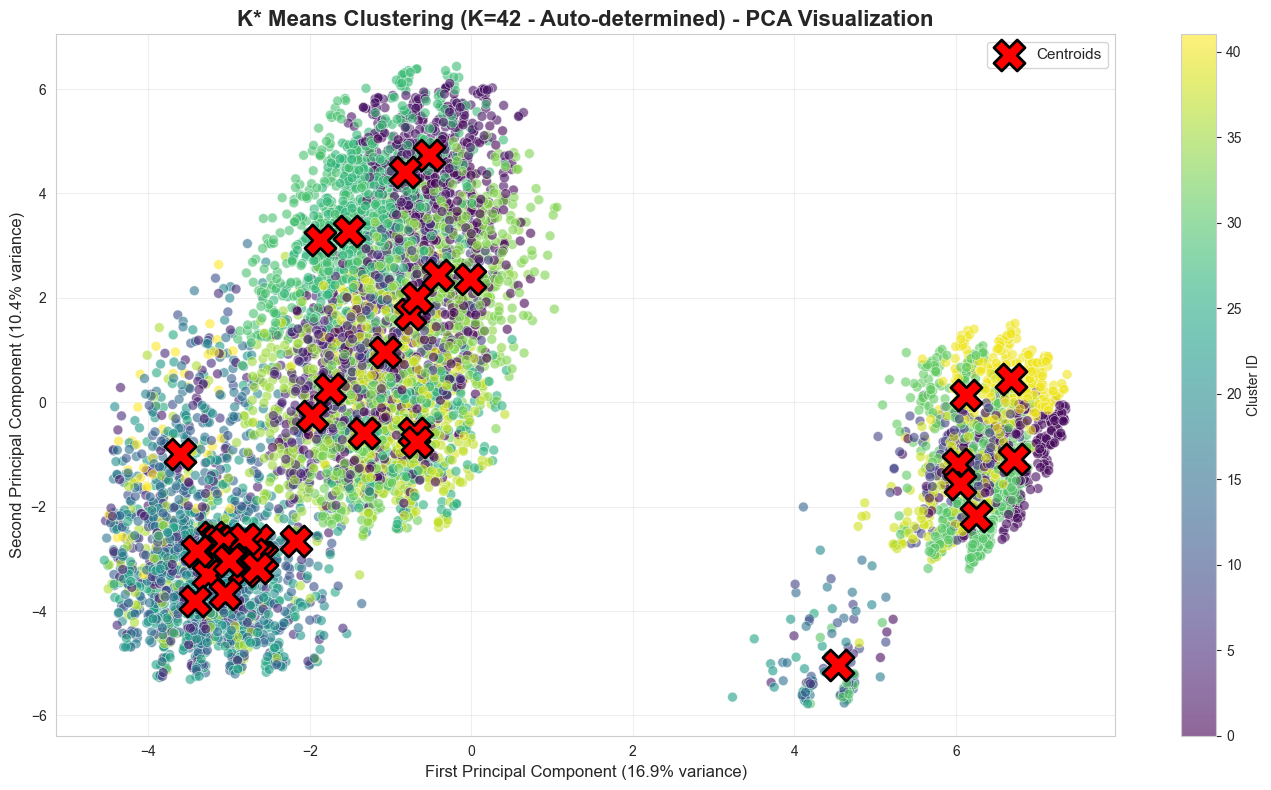

In [70]:
# Apply PCA for 2D visualization
print("Applying PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

# Create visualization
plt.figure(figsize=(14, 8))

# Plot clusters
scatter = plt.scatter(
    pca_components[:, 0], 
    pca_components[:, 1], 
    c=labels, 
    cmap='viridis', 
    alpha=0.6,
    s=50,
    edgecolors='w',
    linewidth=0.5
)

# Plot cluster centers (transformed to PCA space)
if optimal_k > 0:
    centers_pca = pca.transform(np.array(kstar.centroids))
    plt.scatter(
        centers_pca[:, 0], 
        centers_pca[:, 1], 
        c='red', 
        marker='X', 
        s=500, 
        edgecolors='black',
        linewidth=2,
        label='Centroids',
        zorder=10
    )

plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
plt.title(f'K* Means Clustering (K={optimal_k} - Auto-determined) - PCA Visualization', fontsize=16, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
if optimal_k > 0:
    plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Save K* Means Clustering Results

In [71]:
# Save clustering results
output_file = r"C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv"

# Create results DataFrame
results_df = df.copy()
results_df['Cluster'] = labels
results_df['PCA_1'] = pca_components[:, 0]
results_df['PCA_2'] = pca_components[:, 1]

# Save to CSV
results_df.to_csv(output_file, index=False)

print(f"✓ K* Means clustering results saved to: {output_file}")
print(f"  - Total rows: {len(results_df):,}")
print(f"  - Total columns: {len(results_df.columns)} (including Cluster, PCA_1, PCA_2)")
print(f"  - Number of clusters: {optimal_k}")

# Summary statistics by cluster
if optimal_k > 1:
    print("\n" + "="*60)
    print("SUMMARY BY CLUSTER:")
    print("="*60)
    for cluster_id in sorted(results_df['Cluster'].unique()):
        cluster_data = results_df[results_df['Cluster'] == cluster_id]
        print(f"\nCluster {cluster_id}:")
        print(f"  Size: {len(cluster_data):,} samples ({len(cluster_data)/len(results_df)*100:.1f}%)")
        print(f"  PCA_1 mean: {cluster_data['PCA_1'].mean():.4f} ± {cluster_data['PCA_1'].std():.4f}")
        print(f"  PCA_2 mean: {cluster_data['PCA_2'].mean():.4f} ± {cluster_data['PCA_2'].std():.4f}")

✓ K* Means clustering results saved to: C:\Users\weezh\OneDrive\Desktop\pyhercules\dataset\3rd exploration mdl implimentation\kstar_clustering_results.csv
  - Total rows: 7,043
  - Total columns: 75 (including Cluster, PCA_1, PCA_2)
  - Number of clusters: 42

SUMMARY BY CLUSTER:

Cluster 0:
  Size: 512 samples (7.3%)
  PCA_1 mean: -0.7640 ± 0.6469
  PCA_2 mean: 1.6877 ± 1.8559

Cluster 1:
  Size: 257 samples (3.6%)
  PCA_1 mean: 6.7153 ± 0.4614
  PCA_2 mean: -1.0946 ± 0.7607

Cluster 2:
  Size: 330 samples (4.7%)
  PCA_1 mean: -0.5238 ± 0.4546
  PCA_2 mean: 4.7398 ± 0.7653

Cluster 3:
  Size: 154 samples (2.2%)
  PCA_1 mean: -3.1991 ± 1.1845
  PCA_2 mean: -2.5865 ± 1.6206

Cluster 4:
  Size: 258 samples (3.7%)
  PCA_1 mean: -1.7544 ± 0.3834
  PCA_2 mean: 0.2551 ± 1.0256

Cluster 5:
  Size: 130 samples (1.8%)
  PCA_1 mean: -2.9718 ± 1.5065
  PCA_2 mean: -2.9382 ± 1.6457

Cluster 6:
  Size: 19 samples (0.3%)
  PCA_1 mean: -3.2564 ± 0.5637
  PCA_2 mean: -3.3062 ± 1.4956

Cluster 7:
  Siz

## Comparison with Regular K-Means

Let's compare K* Means results with regular K-Means using K=4 (optimal value from previous elbow method analysis).

In [72]:
from sklearn.cluster import KMeans

# Run regular K-Means with K=4 (optimal value from previous analysis)
if optimal_k > 1:
    optimal_k_regular = 4  # Optimal K from previous elbow method analysis
    print(f"Running regular K-Means with K={optimal_k_regular} for comparison...")
    regular_kmeans = KMeans(n_clusters=optimal_k_regular, random_state=42, n_init=10, max_iter=300)
    regular_labels = regular_kmeans.fit_predict(X)
    
    # Calculate metrics for regular K-Means
    regular_silhouette = silhouette_score(X, regular_labels)
    regular_davies_bouldin = davies_bouldin_score(X, regular_labels)
    regular_calinski_harabasz = calinski_harabasz_score(X, regular_labels)
    regular_inertia = regular_kmeans.inertia_
    
    # Display comparison
    print("\n" + "="*80)
    print("COMPARISON: K* MEANS vs REGULAR K-MEANS")
    print("="*80)
    print(f"{'Metric':<35} {'K* Means':<20} {'Regular K-Means':<20}")
    print("-"*80)
    print(f"{'Number of Clusters (K)':<35} {optimal_k:<20} {optimal_k_regular:<20}")
    print(f"{'Silhouette Score':<35} {silhouette:<20.4f} {regular_silhouette:<20.4f}")
    print(f"{'Davies-Bouldin Index':<35} {davies_bouldin:<20.4f} {regular_davies_bouldin:<20.4f}")
    print(f"{'Calinski-Harabasz Score':<35} {calinski_harabasz:<20.2f} {regular_calinski_harabasz:<20.2f}")
    print(f"{'Inertia (WCSS)':<35} {inertia:<20.2f} {regular_inertia:<20.2f}")
    print("="*80)
    
    # Determine which is better
    print("\n📊 Performance Summary:")
    if silhouette > regular_silhouette:
        print(f"  ✓ K* Means has BETTER Silhouette Score ({silhouette:.4f} vs {regular_silhouette:.4f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Silhouette Score ({regular_silhouette:.4f} vs {silhouette:.4f})")
    
    if davies_bouldin < regular_davies_bouldin:
        print(f"  ✓ K* Means has BETTER Davies-Bouldin Index ({davies_bouldin:.4f} vs {regular_davies_bouldin:.4f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Davies-Bouldin Index ({regular_davies_bouldin:.4f} vs {davies_bouldin:.4f})")
    
    if calinski_harabasz > regular_calinski_harabasz:
        print(f"  ✓ K* Means has BETTER Calinski-Harabasz Score ({calinski_harabasz:.2f} vs {regular_calinski_harabasz:.2f})")
    else:
        print(f"  ✗ Regular K-Means has BETTER Calinski-Harabasz Score ({regular_calinski_harabasz:.2f} vs {calinski_harabasz:.2f})")
else:
    print("⚠ Skipping comparison - only one cluster found by K* Means")

Running regular K-Means with K=4 for comparison...



COMPARISON: K* MEANS vs REGULAR K-MEANS
Metric                              K* Means             Regular K-Means     
--------------------------------------------------------------------------------
Number of Clusters (K)              42                   4                   
Silhouette Score                    0.1418               0.1911              
Davies-Bouldin Index                1.8162               2.2800              
Calinski-Harabasz Score             311.65               907.81              
Inertia (WCSS)                      179495.84            365631.47           

📊 Performance Summary:
  ✗ Regular K-Means has BETTER Silhouette Score (0.1911 vs 0.1418)
  ✓ K* Means has BETTER Davies-Bouldin Index (1.8162 vs 2.2800)
  ✗ Regular K-Means has BETTER Calinski-Harabasz Score (907.81 vs 311.65)


## Key Advantages of K* Means

**Automatic K Selection:**
- K* Means automatically determines the optimal number of clusters using MDL principle
- No need for manual tuning or elbow method analysis
- Balances model complexity with data fit

**MDL-Based Optimization:**
- Minimizes description length: Model Cost + Data Encoding Cost
- Prevents overfitting by penalizing excessive clusters
- Adaptive splitting and merging of clusters during training